In [4]:
import pandas as pd
import random 
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [5]:
SEED=42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 1) LOAD FEATURES & LABELS
features = pd.read_csv('train_values.csv')
labels   = pd.read_csv('train_labels.csv')

# 2) MERGE
df = pd.concat([features, labels['damage_grade']], axis=1)

# 3) ZERO-BASE THE TARGET (1→0, 2→1, 3→2)
df['damage_grade'] = df['damage_grade']-1

# 4) SPLIT INTO TRAIN/VAL
X = df.drop('damage_grade', axis=1)
y = df['damage_grade']   # now contains only 0, 1, 2

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [6]:
df_test = pd.read_csv('test_values.csv')

In [7]:
ids     = df_test['building_id'].values
ids

array([ 300051,   99355,  890251, ..., 1049160,  442785,  501372])

In [8]:
X_test  = df_test

In [9]:
column_names = list(df.drop('damage_grade', axis=1).columns)
multi_class_columns = [col for col in column_names if df[col].dtype=='object' and df[col].nunique()>2]
binary_columns = [col for col in column_names if df[col].dtype=='object' and df[col].nunique()==2]
num_columns = [col for col in column_names if df[col].dtype!='object']
print(f"Multi Class columns: {multi_class_columns}")
print(f"Binary columns: {binary_columns}")
print(f"Numerical columns: {num_columns}")

Multi Class columns: ['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status']
Binary columns: []
Numerical columns: ['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_post', '

In [10]:
def build_plain_mlp(input_dim, **kwargs):
    from tensorflow.keras import Input, Sequential
    from tensorflow.keras.layers import Dense
    from tensorflow.keras.optimizers import Adam

    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),
        Dense(32,  activation='relu'),
        Dense(3,   activation='softmax'),
    ])
    print(input_dim)
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(),
        metrics=['accuracy']
    )
    return model


In [11]:
from sklearn.pipeline       import Pipeline
from scikeras.wrappers     import KerasClassifier
from sklearn.compose        import ColumnTransformer
from sklearn.preprocessing  import OneHotEncoder, OrdinalEncoder, StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import pandas as pd

# 1) Build & fit your preprocessor to get the output dim:
preprocessor = ColumnTransformer([
  ('ohe', OneHotEncoder(handle_unknown='ignore'), multi_class_columns),
  ('oe',  OrdinalEncoder(),                         binary_columns),
  ('std', StandardScaler(),                         num_columns)
])
X_train_enc = preprocessor.fit_transform(X_train)
feature_dim = X_train_enc.shape[1]

# 2) Define callbacks
callbacks = [
  EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
  ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
]

# 3) Wrap your model, explicitly passing input_dim
nn = KerasClassifier(
    build_fn=build_plain_mlp,
    input_dim=feature_dim,        # ← here!
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# 4) Assemble the Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   nn)
])

# 5) Fit on raw DataFrame
pipeline.fit(X_train, y_train)

# 6) Plot history

69
Epoch 1/20


/home/sbaniya/.local/lib/python3.11/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
2025-04-26 19:32:52.083201: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


652/652 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5845 - loss: 0.8181 - val_accuracy: 0.6308 - val_loss: 0.7564 - learning_rate: 0.0010
Epoch 2/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6270 - loss: 0.7555 - val_accuracy: 0.6411 - val_loss: 0.7462 - learning_rate: 0.0010
Epoch 3/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6380 - loss: 0.7422 - val_accuracy: 0.6514 - val_loss: 0.7335 - learning_rate: 0.0010
Epoch 4/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6512 - loss: 0.7272 - val_accuracy: 0.6612 - val_loss: 0.7169 - learning_rate: 0.0010
Epoch 5/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6621 - loss: 0.7111 - val_accuracy: 0.6677 - val_loss: 0.7079 - learning_rate: 0.0010
Epoch 6/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6685 - loss: 0.7008 - val_accuracy: 0.6709 - val_loss: 0.7038 - learning_rate: 0.0010
Epoch 7/20
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6723 - loss: 0.6939 - val_accurac

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['land_surface_condition',
                                                   'foundation_type',
                                                   'roof_type',
                                                   'ground_floor_type',
                                                   'other_floor_type',
                                                   'position',
                                                   'plan_configuration',
                                                   'legal_ownership_status']),
                                                 ('oe', OrdinalEncoder(), []),
                                                 ('std', StandardScaler(),
                                                  ['building_id',
                                                   'geo_level_1_id',
                                                   'ge...
                                                   'has_secondary_use_use_police', ...])])),
                ('classifier',
                 KerasClassifier(batch_size=256, build_fn=<function build_plain_mlp at 0x14db121a05e0>, callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x14db12a79990>, <keras.src.callbacks.reduce_lr_on_plateau.ReduceLROnPlateau object at 0x14db13ce3c90>], epochs=20, input_dim=69, validation_split=0.2))])

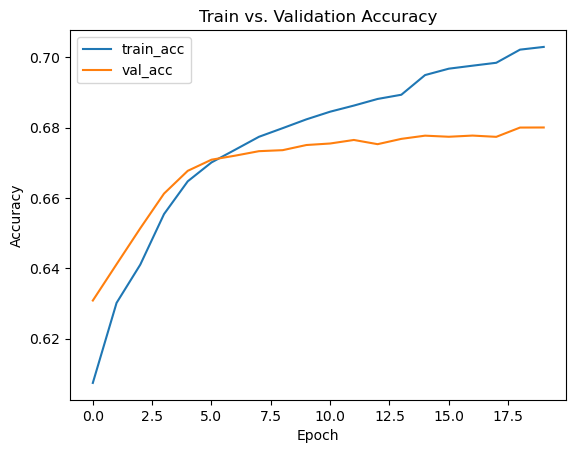

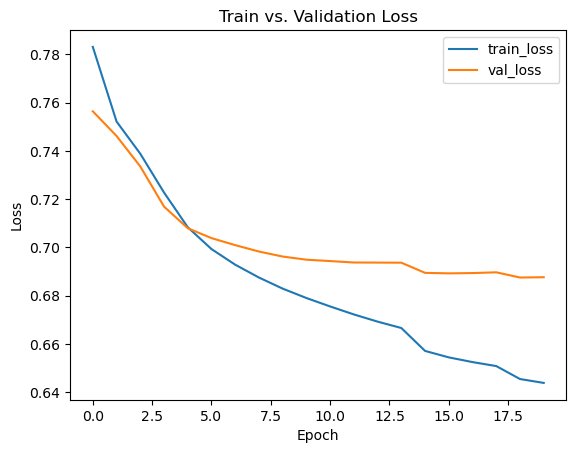

In [12]:
# 1) Grab the history dict directly
hist = pipeline.named_steps['classifier'].history_

# 2) Plot training vs. validation accuracy
import matplotlib.pyplot as plt

plt.figure()
plt.plot(hist['accuracy'],     label='train_acc')
plt.plot(hist['val_accuracy'], label='val_acc')
plt.title('Train vs. Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.show()

# 3) Plot training vs. validation loss
plt.figure()
plt.plot(hist['loss'],     label='train_loss')
plt.plot(hist['val_loss'], label='val_loss')
plt.title('Train vs. Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.show()


In [13]:
# 7) Predict & save MLP6_submission.csv
preds = pipeline.predict(X_test)
pd.DataFrame({
  'building_id': X_test['building_id'].values,
  'damage_grade': preds
}).to_csv('MLP1_submission.csv', index=False)
print("Wrote MLP1_submission.csv")


340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Wrote MLP1_submission.csv


**Adding callbacks to stop after plataeu**

In [14]:
from tensorflow.keras      import Input, Sequential

# --- 0) Define your callbacks (same as before)
callbacks2 = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
]

# --- 1) Build your preprocessor
preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), multi_class_columns),
    ('oe',  OrdinalEncoder(),                         binary_columns),
    ('std', StandardScaler(),                         num_columns)
])

# Fit it once to grab the encoded feature‐dim
X_train_enc = preprocessor.fit_transform(X_train)
feature_dim = X_train_enc.shape[1]

# --- 2) Define a build‐fn for your MLP2
def build_mlp2(input_dim, **kwargs):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),
        Dense(32,  activation='relu'),
        Dense(3,   activation='softmax'),
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(),
        metrics=['accuracy']
    )
    return model

# --- 3) Wrap in SciKeras classifier, passing input_dim explicitly
nn2 = KerasClassifier(
    build_fn=build_mlp2,
    input_dim=feature_dim,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=callbacks2,
    verbose=1
)

# --- 4) Assemble the Pipeline
pipeline2 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   nn2)
])

# --- 5) Fit on raw X_train DataFrame
pipeline2.fit(X_train, y_train)

Epoch 1/50


/home/sbaniya/.local/lib/python3.11/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


652/652 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5838 - loss: 0.8267 - val_accuracy: 0.6337 - val_loss: 0.7557 - learning_rate: 0.0010
Epoch 2/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6302 - loss: 0.7531 - val_accuracy: 0.6487 - val_loss: 0.7395 - learning_rate: 0.0010
Epoch 3/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6481 - loss: 0.7337 - val_accuracy: 0.6598 - val_loss: 0.7202 - learning_rate: 0.0010
Epoch 4/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6615 - loss: 0.7152 - val_accuracy: 0.6656 - val_loss: 0.7107 - learning_rate: 0.0010
Epoch 5/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6675 - loss: 0.7043 - val_accuracy: 0.6693 - val_loss: 0.7057 - learning_rate: 0.0010
Epoch 6/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6722 - loss: 0.6973 - val_accuracy: 0.6719 - val_loss: 0.7019 - learning_rate: 0.0010
Epoch 7/50
652/652 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6756 - loss: 0.6920 - val_accurac

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['land_surface_condition',
                                                   'foundation_type',
                                                   'roof_type',
                                                   'ground_floor_type',
                                                   'other_floor_type',
                                                   'position',
                                                   'plan_configuration',
                                                   'legal_ownership_status']),
                                                 ('oe', OrdinalEncoder(), []),
                                                 ('std', StandardScaler(),
                                                  ['building_id',
                                                   'geo_level_1_id',
                                                   'ge...
                                                   'has_secondary_use_gov_office',
                                                   'has_secondary_use_use_police', ...])])),
                ('classifier',
                 KerasClassifier(batch_size=256, build_fn=<function build_mlp2 at 0x14dafe44e7a0>, callbacks=[<keras.src.callbacks.early_stopping.EarlyStopping object at 0x14db1376a4d0>, <keras.src.callbacks.reduce_lr_on_plateau.ReduceLROnPlateau object at 0x14dafe420710>], epochs=50, input_dim=69, validation_split=0.2))])

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
# — your ColumnTransformer —
preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), multi_class_columns),
    ('oe',  OrdinalEncoder(),                 binary_columns),
    ('std', StandardScaler(),                 num_columns)
])

# — your SciKeras wrapper (using whatever build-fn you chose) —
nn = KerasClassifier(
    build_fn=build_mlp2,      # or get_neural_net, etc.
    input_dim=feature_dim,
    verbose=1
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   nn)
])


In [16]:
X_val_enc = preprocessor.fit_transform(X_val)
# 1) Fit the pipeline, passing all Keras fit args to the 'classifier' step:
pipeline.fit(
    X_train, y_train,
    classifier__validation_data=(X_val_enc, y_val),
    classifier__callbacks=callbacks,
    classifier__epochs=50,
    classifier__batch_size=256
)


Epoch 1/50


/home/sbaniya/.local/lib/python3.11/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


815/815 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5946 - loss: 0.8085 - val_accuracy: 0.6266 - val_loss: 0.7516
Epoch 2/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6344 - loss: 0.7507 - val_accuracy: 0.6533 - val_loss: 0.7233
Epoch 3/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6568 - loss: 0.7228 - val_accuracy: 0.6590 - val_loss: 0.7114
Epoch 4/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6638 - loss: 0.7103 - val_accuracy: 0.6636 - val_loss: 0.7059
Epoch 5/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6691 - loss: 0.7028 - val_accuracy: 0.6667 - val_loss: 0.7027
Epoch 6/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6726 - loss: 0.6975 - val_accuracy: 0.6692 - val_loss: 0.6997
Epoch 7/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6755 - loss: 0.6930 - val_accuracy: 0.6696 - val_loss: 0.6966
Epoch 8/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6779 - loss: 0.6892 - val_accuracy: 0.6726 - val_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['land_surface_condition',
                                                   'foundation_type',
                                                   'roof_type',
                                                   'ground_floor_type',
                                                   'other_floor_type',
                                                   'position',
                                                   'plan_configuration',
                                                   'legal_ownership_status']),
                                                 ('oe', OrdinalEncoder(), []),
                                                 ('std', StandardScaler(),
                                                  ['building_id',
                                                   'geo_level_1_id',
                                                   'ge...
                                                   'has_secondary_use_agriculture',
                                                   'has_secondary_use_hotel',
                                                   'has_secondary_use_rental',
                                                   'has_secondary_use_institution',
                                                   'has_secondary_use_school',
                                                   'has_secondary_use_industry',
                                                   'has_secondary_use_health_post',
                                                   'has_secondary_use_gov_office',
                                                   'has_secondary_use_use_police', ...])])),
                ('classifier',
                 KerasClassifier(build_fn=<function build_mlp2 at 0x14dafe44e7a0>, input_dim=69))])

In [18]:
import pandas as pd

final_preds = pipeline.predict(X_test)

submission2 = pd.DataFrame({
    'building_id': X_test['building_id'].values,
    'damage_grade': final_preds
})
submission2.to_csv('MLP2_submission.csv', index=False)
print("Wrote MLP2_submission.csv")


2715/2715 ━━━━━━━━━━━━━━━━━━━━ 2s 717us/step
Wrote MLP2_submission.csv


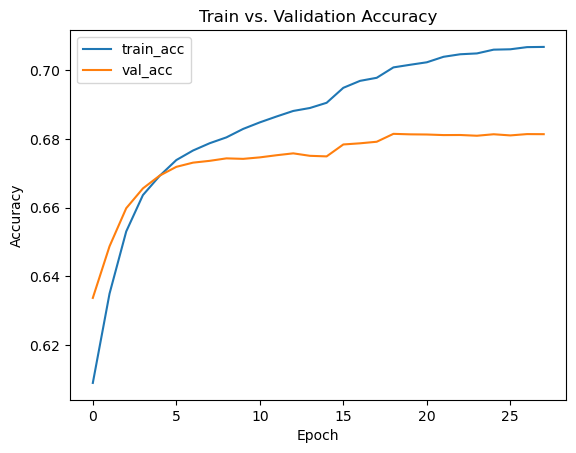

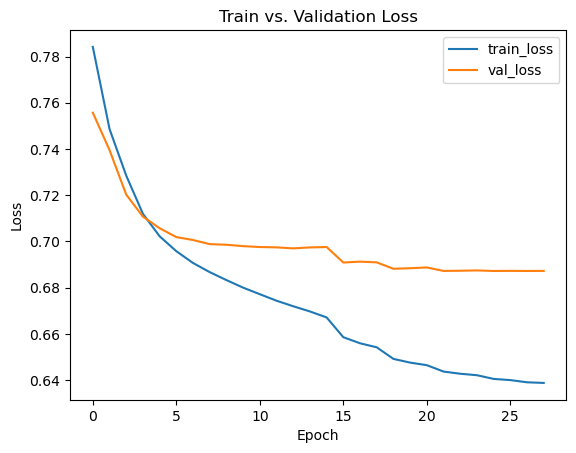

In [19]:
import matplotlib.pyplot as plt

# grab the history from the KerasClassifier
hist = pipeline2.named_steps['classifier'].history_
metrics = hist.history if hasattr(hist, 'history') else hist

# accuracy
plt.figure()
plt.plot(metrics['accuracy'],     label='train_acc')
plt.plot(metrics['val_accuracy'], label='val_acc')
plt.title('Train vs. Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.show()

# loss
plt.figure()
plt.plot(metrics['loss'],     label='train_loss')
plt.plot(metrics['val_loss'], label='val_loss')
plt.title('Train vs. Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.show()

**Injecting dropout (and/or BatchNorm)**

In [20]:
from sklearn.pipeline import Pipeline
from scikeras.wrappers import KerasClassifier
from tensorflow.keras import Input, Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import pandas as pd

# 1) Define your MLP3 build-fn
def build_mlp3():
    model = Sequential([
        Input(shape=(X_train_enc.shape[1],), name="features_in"),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),

        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),

        Dense(3, activation='softmax'),
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(),
        metrics=['accuracy']
    )
    return model

# 2) Wrap it in SciKeras
mlp3 = KerasClassifier(
    build_fn=build_mlp3,
    verbose=1
)

# 3) Build the pipeline
pipeline3 = Pipeline([
    ('preprocessor', preprocessor),  # your existing ColumnTransformer
    ('classifier',   mlp3)
])

# 4) Define callbacks
callbacks3 = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
]

# 5) Fit with validation and callbacks
pipeline3.fit(
    X_train, y_train,
    classifier__validation_data=(X_val_enc, y_val),
    classifier__callbacks=callbacks3,
    classifier__epochs=20,
    classifier__batch_size=256
)


Epoch 1/20


/home/sbaniya/.local/lib/python3.11/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


815/815 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4931 - loss: 1.0773 - val_accuracy: 0.6024 - val_loss: 0.7882
Epoch 2/20
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5864 - loss: 0.8153 - val_accuracy: 0.6121 - val_loss: 0.7716
Epoch 3/20
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5987 - loss: 0.7951 - val_accuracy: 0.6187 - val_loss: 0.7647
Epoch 4/20
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6044 - loss: 0.7867 - val_accuracy: 0.6239 - val_loss: 0.7582
Epoch 5/20
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6121 - loss: 0.7794 - val_accuracy: 0.6286 - val_loss: 0.7517
Epoch 6/20
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6153 - loss: 0.7753 - val_accuracy: 0.6319 - val_loss: 0.7487
Epoch 7/20
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6189 - loss: 0.7702 - val_accuracy: 0.6367 - val_loss: 0.7458
Epoch 8/20
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6216 - loss: 0.7679 - val_accuracy: 0.6407 - val_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['land_surface_condition',
                                                   'foundation_type',
                                                   'roof_type',
                                                   'ground_floor_type',
                                                   'other_floor_type',
                                                   'position',
                                                   'plan_configuration',
                                                   'legal_ownership_status']),
                                                 ('oe', OrdinalEncoder(), []),
                                                 ('std', StandardScaler(),
                                                  ['building_id',
                                                   'geo_level_1_id',
                                                   'ge...
                                                   'has_secondary_use_agriculture',
                                                   'has_secondary_use_hotel',
                                                   'has_secondary_use_rental',
                                                   'has_secondary_use_institution',
                                                   'has_secondary_use_school',
                                                   'has_secondary_use_industry',
                                                   'has_secondary_use_health_post',
                                                   'has_secondary_use_gov_office',
                                                   'has_secondary_use_use_police', ...])])),
                ('classifier',
                 KerasClassifier(build_fn=<function build_mlp3 at 0x14db126cede0>))])

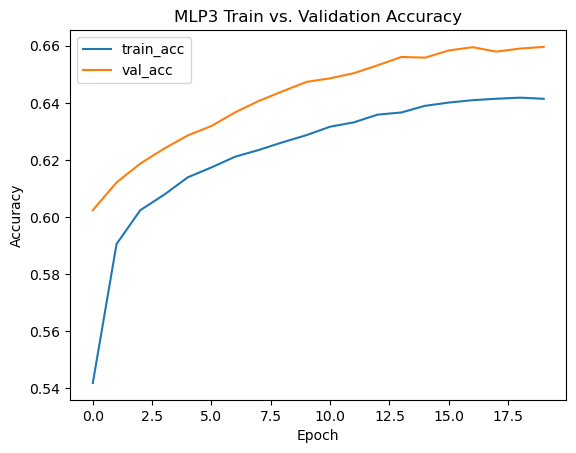

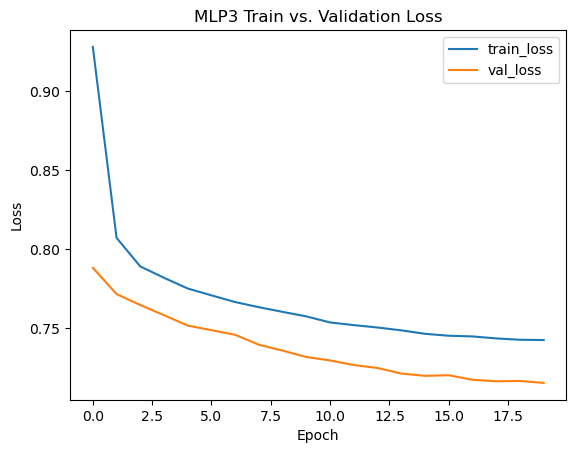

In [21]:
# 6) Extract training history
hist3 = pipeline3.named_steps['classifier'].history_
metrics3 = hist3.history if hasattr(hist3, 'history') else hist3

# 7) Plot accuracy
plt.figure()
plt.plot(metrics3['accuracy'],     label='train_acc')
plt.plot(metrics3['val_accuracy'], label='val_acc')
plt.title('MLP3 Train vs. Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.show()

# 8) Plot loss
plt.figure()
plt.plot(metrics3['loss'],     label='train_loss')
plt.plot(metrics3['val_loss'], label='val_loss')
plt.title('MLP3 Train vs. Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.show()

In [22]:
# 9) Generate & save MLP3 submission
final_preds3 = pipeline3.predict(X_test)
submission3 = pd.DataFrame({
    'building_id': X_test['building_id'].values,
    'damage_grade': final_preds3
})
submission3.to_csv('MLP3_submission.csv', index=False)
print("Wrote MLP3_submission.csv")


2715/2715 ━━━━━━━━━━━━━━━━━━━━ 2s 816us/step
Wrote MLP3_submission.csv


In [23]:
from sklearn.pipeline       import Pipeline
from scikeras.wrappers     import KerasClassifier
from tensorflow.keras       import Input, Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks  import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot    as plt
import pandas               as pd

# 1) Define the MLP3 builder
def build_mlp3():
    model = Sequential([
        Input(shape=(X_train_enc.shape[1],)),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),

        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),

        Dense(3, activation='softmax'),
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(),
        metrics=['accuracy']
    )
    return model

# 2) Wrap in SciKeras and build pipeline
mlp3 = KerasClassifier(build_fn=build_mlp3, verbose=1)

pipeline4 = Pipeline([
    ('preprocessor', preprocessor),  # your existing ColumnTransformer
    ('classifier',   mlp3),
])

# 3) Callbacks for MLP3
callbacks4 = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
]

# 4) Fit with validation passed into the classifier step
pipeline4.fit(
    X_train, y_train,
    classifier__validation_data=(X_val_enc, y_val),
    classifier__callbacks=callbacks3,
    classifier__epochs=20,
    classifier__batch_size=256
)

Epoch 1/20


/home/sbaniya/.local/lib/python3.11/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


815/815 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4802 - loss: 1.1109 - val_accuracy: 0.6040 - val_loss: 0.7908
Epoch 2/20
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5840 - loss: 0.8197 - val_accuracy: 0.6090 - val_loss: 0.7752
Epoch 3/20
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5975 - loss: 0.7966 - val_accuracy: 0.6159 - val_loss: 0.7653
Epoch 4/20
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6043 - loss: 0.7872 - val_accuracy: 0.6207 - val_loss: 0.7593
Epoch 5/20
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6092 - loss: 0.7818 - val_accuracy: 0.6245 - val_loss: 0.7564
Epoch 6/20
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6112 - loss: 0.7776 - val_accuracy: 0.6285 - val_loss: 0.7533
Epoch 7/20
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6141 - loss: 0.7741 - val_accuracy: 0.6313 - val_loss: 0.7490
Epoch 8/20
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6185 - loss: 0.7713 - val_accuracy: 0.6368 - val_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['land_surface_condition',
                                                   'foundation_type',
                                                   'roof_type',
                                                   'ground_floor_type',
                                                   'other_floor_type',
                                                   'position',
                                                   'plan_configuration',
                                                   'legal_ownership_status']),
                                                 ('oe', OrdinalEncoder(), []),
                                                 ('std', StandardScaler(),
                                                  ['building_id',
                                                   'geo_level_1_id',
                                                   'ge...
                                                   'has_secondary_use_agriculture',
                                                   'has_secondary_use_hotel',
                                                   'has_secondary_use_rental',
                                                   'has_secondary_use_institution',
                                                   'has_secondary_use_school',
                                                   'has_secondary_use_industry',
                                                   'has_secondary_use_health_post',
                                                   'has_secondary_use_gov_office',
                                                   'has_secondary_use_use_police', ...])])),
                ('classifier',
                 KerasClassifier(build_fn=<function build_mlp3 at 0x14daf71fd940>))])

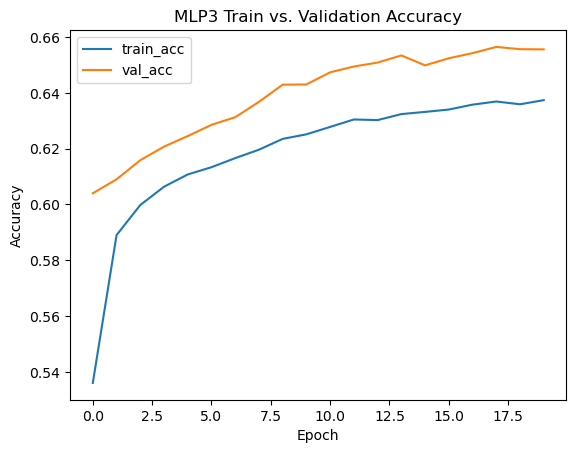

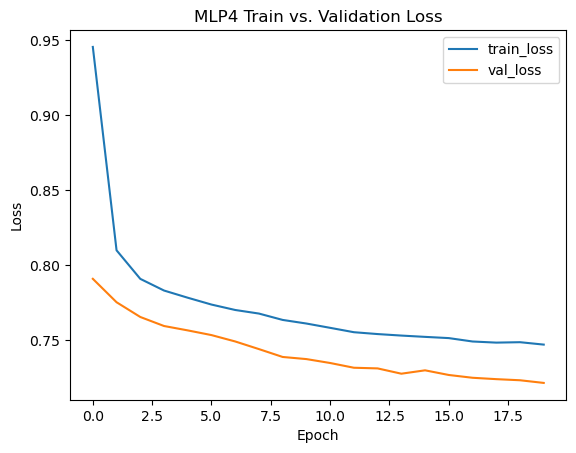

In [24]:
# 5) Extract history and plot
hist4   = pipeline4.named_steps['classifier'].history_
metrics4 = hist4.history if hasattr(hist3, 'history') else hist4

# Accuracy plot
plt.figure()
plt.plot(metrics4['accuracy'],     label='train_acc')
plt.plot(metrics4['val_accuracy'], label='val_acc')
plt.title('MLP3 Train vs. Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.show()

# Loss plot
plt.figure()
plt.plot(metrics4['loss'],     label='train_loss')
plt.plot(metrics4['val_loss'], label='val_loss')
plt.title('MLP4 Train vs. Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.show()

In [25]:
# 6) Save submission as MLP3_submission.csv
final_pred4 = pipeline4.predict(X_test)
submission3  = pd.DataFrame({
    'building_id': X_test['building_id'].values,
    'damage_grade': final_preds3
})
submission3.to_csv('MLP4_submission.csv', index=False)
print("Wrote MLP4_submission.csv")


2715/2715 ━━━━━━━━━━━━━━━━━━━━ 2s 750us/step
Wrote MLP4_submission.csv


In [26]:
from sklearn.pipeline       import Pipeline
from scikeras.wrappers     import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam

# A) Adapt build_wider_model to accept x_shape
def build_wider_model(x_shape, **kwargs):
    input_dim = x_shape[1]
    m = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(3, activation='softmax'),
    ])
    m.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=1e-3),
        metrics=['accuracy']
    )
    return m

# B) Wrap in SciKeras
mlp5 = KerasClassifier(
    build_fn=build_wider_model,
    verbose=1
)

# C) Pipeline: preprocessing + model
pipeline5 = Pipeline([
    ('preprocessor', preprocessor),  # your ColumnTransformer
    ('classifier',   mlp3)
])


In [27]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
]

pipeline5.fit(
    X_train, y_train,
    classifier__validation_data=(X_val_enc, y_val),
    classifier__callbacks=callbacks,
    classifier__epochs=50,
    classifier__batch_size=256
)


Epoch 1/50


/home/sbaniya/.local/lib/python3.11/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


815/815 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4816 - loss: 1.0952 - val_accuracy: 0.6055 - val_loss: 0.7958
Epoch 2/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5837 - loss: 0.8187 - val_accuracy: 0.6153 - val_loss: 0.7737
Epoch 3/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5969 - loss: 0.7960 - val_accuracy: 0.6194 - val_loss: 0.7631
Epoch 4/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6010 - loss: 0.7884 - val_accuracy: 0.6241 - val_loss: 0.7587
Epoch 5/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6059 - loss: 0.7823 - val_accuracy: 0.6253 - val_loss: 0.7544
Epoch 6/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6104 - loss: 0.7769 - val_accuracy: 0.6276 - val_loss: 0.7520
Epoch 7/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6119 - loss: 0.7752 - val_accuracy: 0.6298 - val_loss: 0.7486
Epoch 8/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6159 - loss: 0.7715 - val_accuracy: 0.6321 - val_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['land_surface_condition',
                                                   'foundation_type',
                                                   'roof_type',
                                                   'ground_floor_type',
                                                   'other_floor_type',
                                                   'position',
                                                   'plan_configuration',
                                                   'legal_ownership_status']),
                                                 ('oe', OrdinalEncoder(), []),
                                                 ('std', StandardScaler(),
                                                  ['building_id',
                                                   'geo_level_1_id',
                                                   'ge...
                                                   'has_secondary_use_agriculture',
                                                   'has_secondary_use_hotel',
                                                   'has_secondary_use_rental',
                                                   'has_secondary_use_institution',
                                                   'has_secondary_use_school',
                                                   'has_secondary_use_industry',
                                                   'has_secondary_use_health_post',
                                                   'has_secondary_use_gov_office',
                                                   'has_secondary_use_use_police', ...])])),
                ('classifier',
                 KerasClassifier(build_fn=<function build_mlp3 at 0x14daf71fd940>))])

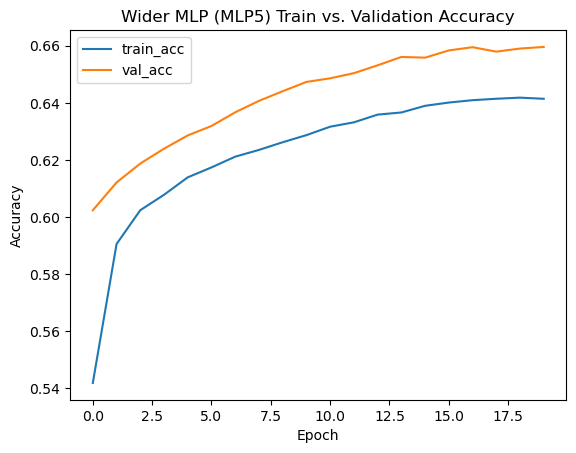

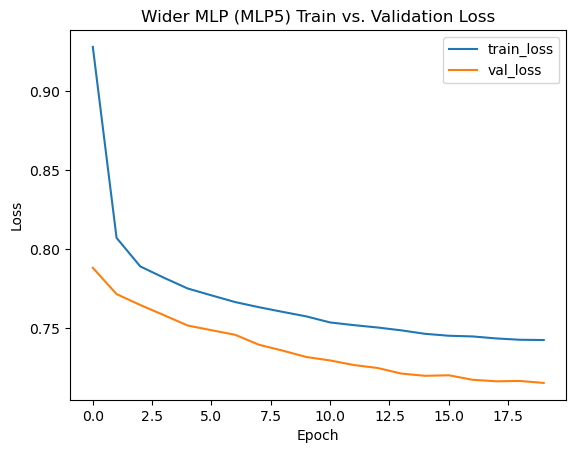

In [28]:
import matplotlib.pyplot as plt

hist5    = pipeline3.named_steps['classifier'].history_
metrics5 = hist5.history if hasattr(hist3, 'history') else hist5

# Accuracy
plt.figure()
plt.plot(metrics5['accuracy'],     label='train_acc')
plt.plot(metrics5['val_accuracy'], label='val_acc')
plt.title('Wider MLP (MLP5) Train vs. Validation Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.show()

# Loss
plt.figure()
plt.plot(metrics5['loss'],     label='train_loss')
plt.plot(metrics5['val_loss'], label='val_loss')
plt.title('Wider MLP (MLP5) Train vs. Validation Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.show()


In [29]:
final_preds5 = pipeline5.predict(X_test)
submission5  = pd.DataFrame({
    'building_id': X_test['building_id'].values,
    'damage_grade': final_preds3
})
submission5.to_csv('MLP5_submission.csv', index=False)
print("Wrote MLP5_submission.csv")

2715/2715 ━━━━━━━━━━━━━━━━━━━━ 2s 741us/step
Wrote MLP5_submission.csv


Epoch 1/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5392 - loss: 0.9561 - val_accuracy: 0.6144 - val_loss: 0.7709 - learning_rate: 0.0010
Epoch 2/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6115 - loss: 0.7827 - val_accuracy: 0.6232 - val_loss: 0.7547 - learning_rate: 0.0010
Epoch 3/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6228 - loss: 0.7663 - val_accuracy: 0.6311 - val_loss: 0.7454 - learning_rate: 0.0010
Epoch 4/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6288 - loss: 0.7564 - val_accuracy: 0.6411 - val_loss: 0.7351 - learning_rate: 0.0010
Epoch 5/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6378 - loss: 0.7470 - val_accuracy: 0.6551 - val_loss: 0.7209 - learning_rate: 0.0010
Epoch 6/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6486 - loss: 0.7343 - val_accuracy: 0.6650 - val_loss: 0.7101 - learning_rate: 0.0010
Epoch 7/50
815/815 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6531 - loss: 0.7257 - 

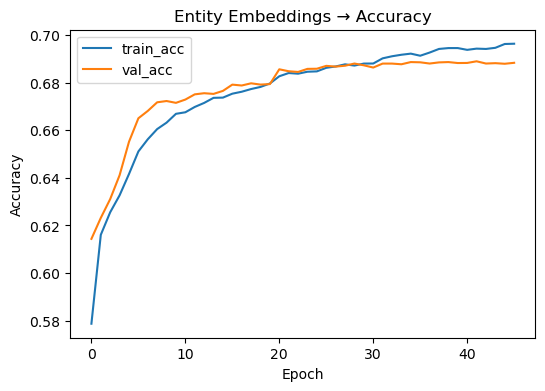

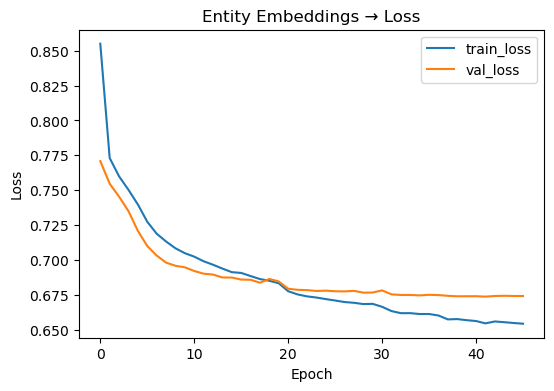

In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# 1) Load & zero-base
feat = pd.read_csv('train_values.csv')
lbl  = pd.read_csv('train_labels.csv')
df   = pd.concat([feat, lbl['damage_grade']], axis=1)
df['damage_grade'] -= 1

# 2) Train/val split
X = df.drop('damage_grade', axis=1)
y = df['damage_grade']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2,
                                            stratify=y, random_state=42)

# 3) Identify columns
multi_cols  = [c for c in X.columns if X[c].dtype=='object' and X[c].nunique()>2]
binary_cols = [c for c in X.columns if X[c].dtype=='object' and X[c].nunique()==2]
num_cols    = [c for c in X.columns if X[c].dtype!='object']

# 4) Label-encode each categorical (in place)
labelers = {}
for col in multi_cols + binary_cols:
    le = LabelEncoder()
    X_train[col]  = le.fit_transform(X_train[col])
    X_val[col] = le.transform(X_val[col])
    labelers[col] = le

# 5) Scale numerics
scaler = StandardScaler()
X_train[num_cols]  = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])

# 6) Build embedding inputs
inputs, embeddings = [], []
for col in multi_cols:
    num_unique = X_train[col].nunique()
    embed_dim  = min(50, (num_unique+1)//2)   # a heuristic
    inp = Input(shape=(1,), name=f"{col}_in")
    emb = Embedding(input_dim=num_unique, output_dim=embed_dim, name=f"{col}_emb")(inp)
    emb = Flatten()(emb)
    inputs.append(inp)
    embeddings.append(emb)

# 7) Binary categoricals & numerics as one vector
if binary_cols:
    inp_bin = Input(shape=(len(binary_cols),), name="bin_in")
    inputs.append(inp_bin)
    embeddings.append(inp_bin)
if num_cols:
    inp_num = Input(shape=(len(num_cols),), name="num_in")
    inputs.append(inp_num)
    embeddings.append(inp_num)

# 8) Concatenate & Dense stack
x = Concatenate()(embeddings)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
out = Dense(3, activation='softmax')(x)

model = Model(inputs, out)
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(1e-3),
    metrics=['accuracy']
)

# 9) Prepare fit inputs
fit_train = [X_train[col].values for col in multi_cols]
if binary_cols: fit_train.append(X_train[binary_cols].values)
if num_cols:    fit_train.append(X_train[num_cols].values)

fit_val = [X_val[col].values for col in multi_cols]
if binary_cols: fit_val.append(X_val[binary_cols].values)
if num_cols:    fit_val.append(X_val[num_cols].values)

# 10) Callbacks & train
cbs = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
]
hist = model.fit(
    fit_train, y_train,
    validation_data=(fit_val, y_val),
    epochs=50,
    batch_size=256,
    callbacks=cbs,
    verbose=1
)

# 11) Plot
plt.figure(figsize=(6,4))
plt.plot(hist.history['accuracy'],    label='train_acc')
plt.plot(hist.history['val_accuracy'],label='val_acc')
plt.title('Entity Embeddings → Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(hist.history['loss'],    label='train_loss')
plt.plot(hist.history['val_loss'],label='val_loss')
plt.title('Entity Embeddings → Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.show()


In [31]:
import pandas as pd
import numpy as np

# 1) Load your test set (adjust path as needed)
test_df = pd.read_csv('test_values.csv')

# 2) Apply the same LabelEncoders and scaler you used for train/val
for col, le in labelers.items():
    test_df[col] = le.transform(test_df[col].astype(str))

test_df[num_cols] = scaler.transform(test_df[num_cols])

# 3) Prepare the list of inputs in the same order as for training
fit_test = [test_df[col].values for col in multi_cols]
if binary_cols:
    fit_test.append(test_df[binary_cols].values)
if num_cols:
    fit_test.append(test_df[num_cols].values)

# 4) Predict probabilities and take the argmax
probs6 = model.predict(fit_test)      # shape (n_samples, 3)
preds6 = np.argmax(probs6, axis=1)    # class indices 0,1,2

# 5) Build & write the submission file
submission6 = pd.DataFrame({
    'building_id': test_df['building_id'].values,
    'damage_grade': preds6
})
submission6.to_csv('MLP6_submission.csv', index=False)
print("Wrote MLP6_submission.csv")


2715/2715 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Wrote MLP6_submission.csv


In [32]:
# import tensorflow as tf
# from tensorflow.keras     import Input, Model
# from tensorflow.keras.layers import (
#     Dense, Embedding, Flatten,
#     Concatenate, Dropout,
#     BatchNormalization, Lambda
# )
# from tensorflow.keras.optimizers import Adam

# # Precompute sizes
# category_sizes = {c: X_train[c].nunique() for c in multi_class_columns}
# start_idx = {  # map each column to its offset in the encoded array
#     c: i for i, c in enumerate(multi_class_columns + binary_columns + num_columns)
# }

# def build_embedding_model(input_dim):
#     all_in = Input(shape=(input_dim,), name="features")
#     embs, used = [], 0

#     # embeddings for each categorical
#     for col in multi_class_columns:
#         size = category_sizes[col]
#         dim  = min(50, (size+1)//2)

#         slice_i = Lambda(lambda x, s=used: x[:, s:s+1])(all_in)
#         used += 1

#         e = Embedding(size, dim)(slice_i)
#         embs.append(Flatten()(e))

#     # binaries
#     if binary_columns:
#         bin_slice = Lambda(lambda x, s=used, n=len(binary_columns): x[:, s:s+n])(all_in)
#         embs.append(bin_slice)
#         used += len(binary_columns)

#     # numerics
#     if num_columns:
#         num_slice = Lambda(lambda x, s=used, n=len(num_columns): x[:, s:s+n])(all_in)
#         embs.append(num_slice)

#     x = Concatenate()(embs)
#     for units in (256, 128):
#         x = Dense(units, activation='relu')(x)
#         x = BatchNormalization()(x)
#         x = Dropout(0.2)(x)
#     out = Dense(3, activation='softmax')(x)

#     m = Model(all_in, out)
#     m.compile(
#       loss='sparse_categorical_crossentropy',
#       optimizer=Adam(1e-3),
#       metrics=['accuracy']
#     )
#     return m

# model = build_embedding_model(X_train_enc.shape[1])


In [33]:
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# callbacks = [
#   EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
#   ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
# ]

# history = model.fit(
#   X_train_enc, y_train,
#   validation_data=(X_val_enc, y_val),
#   epochs=50,
#   batch_size=256,
#   callbacks=callbacks,
#   verbose=1
# )


In [34]:
# import matplotlib.pyplot as plt

# plt.figure()
# plt.plot(history.history['accuracy'],    label='train_acc')
# plt.plot(history.history['val_accuracy'],label='val_acc')
# plt.legend(); plt.title('Accuracy'); plt.show()

# plt.figure()
# plt.plot(history.history['loss'],    label='train_loss')
# plt.plot(history.history['val_loss'],label='val_loss')
# plt.legend(); plt.title('Loss'); plt.show()


In [35]:
# import numpy as np, pandas as pd

# probs = model.predict(X_test_enc)            # shape (n_test, 3)
# preds = np.argmax(probs, axis=1)

# pd.DataFrame({
#   'building_id': X_test['building_id'].values,
#   'damage_grade': preds
# }).to_csv('MLP6_submission.csv', index=False)

# print("Wrote MLP6_submission.csv")


In [36]:
# from kerastuner import HyperModel, RandomSearch
# from tensorflow.keras.layers import Input, Embedding, Flatten, Dense, Dropout, BatchNormalization, Concatenate
# from tensorflow.keras.models import Model
# from tensorflow.keras.optimizers import Adam

# class TabularHyper(HyperModel):
#     def __init__(self, multi_cols, num_cols, labelers, scaler):
#         self.multi_cols = multi_cols
#         self.num_cols   = num_cols
#         self.labelers   = labelers
#         self.scaler     = scaler

#     def build(self, hp):
#         # --- Inputs + Embeddings ---
#         inputs, embs = [], []
#         for col in self.multi_cols:
#             num_unique = len(self.labelers[col].classes_)
#             emb_dim    = hp.Int(f"{col}_dim", 4, min(num_unique, 64), step=4)
#             inp = Input(shape=(1,), name=f"{col}_in")
#             emb = Embedding(num_unique, emb_dim)(inp)
#             emb = Flatten()(emb)
#             inputs.append(inp)
#             embs.append(emb)

#         # Numeric inputs
#         inp_num = Input(shape=(len(self.num_cols),), name="num_in")
#         inputs.append(inp_num)
#         embs.append(inp_num)

#         # --- Concatenate & Dense Stack ---
#         x = Concatenate()(embs)
#         for i in range(hp.Int("n_layers", 1, 3)):
#             units = hp.Int(f"units_{i}", 32, 512, step=32)
#             x = Dense(units, activation="relu")(x)
#             if hp.Boolean(f"batchnorm_{i}"):
#                 x = BatchNormalization()(x)
#             x = Dropout(hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1))(x)

#         out = Dense(3, activation="softmax")(x)
#         model = Model(inputs, out)
#         model.compile(
#             optimizer=Adam(hp.Float("lr", 1e-4, 1e-2, sampling="log")),
#             loss="sparse_categorical_crossentropy",
#             metrics=["accuracy"]
#         )
#         return model

# # Prepare your labelers and scaler as you did before...
# hyper = TabularHyper(multi_cols, num_cols, labelers, scaler)

# tuner = RandomSearch(
#     hyper,
#     objective="val_accuracy",
#     max_trials=20,
#     executions_per_trial=1,
#     directory="kt_tuning",
#     project_name="damage_nn"
# )

# # Build your fit arrays just like before:
# fit_tr = [X_tr[col].values for col in multi_cols] + [X_tr[num_cols].values]
# fit_val = [X_val[col].values for col in multi_cols] + [X_val[num_cols].values]

# tuner.search(
#     fit_tr, y_tr,
#     validation_data=(fit_val, y_val),
#     epochs=30,
#     batch_size=hp.Choice("batch_size", [64,128,256]),
#     callbacks=cbs,  # your EarlyStopping & ReduceLROnPlateau
# )

# best_model = tuner.get_best_models(num_models=1)[0]


In [37]:
from kerastuner import HyperModel, RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters
from tensorflow.keras.layers import (
    Input, Embedding, Flatten,
    Dense, Dropout, BatchNormalization, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1) Define the HyperModel (adding batch_size to the hyperparameters)
class TabularHyper(HyperModel):
    def __init__(self, multi_cols, num_cols, labelers, scaler):
        self.multi_cols = multi_cols
        self.num_cols   = num_cols
        self.labelers   = labelers
        self.scaler     = scaler

    def build(self, hp):
        inputs, embs = [], []
        # Embedding inputs
        for col in self.multi_cols:
            vocab_size = len(self.labelers[col].classes_)
            # pick a sensible minimum: 4 only if you actually have ≥4 categories
            max_dim= min(vocab_size, 64)
            min_dim = 4 if max_dim >= 4 else 1                    # → 1
            emb_dim = hp.Int(
                f"{col}_dim",
                min_value=min_dim,
                max_value=max_dim,
                # you can drop `step=4` or set step=1 here since ranges are small
            )
            inp   = Input(shape=(1,), name=f"{col}_in")
            emb   = Embedding(input_dim=vocab_size, output_dim=emb_dim, name=f"{col}_emb")(inp)
            emb   = Flatten()(emb)
            
            inputs.append(inp) 
            embs.append(emb)

        # Numeric input
        inp_num = Input(shape=(len(self.num_cols),), name="num_in")
        inputs.append(inp_num); embs.append(inp_num)

        # Dense stack
        x = Concatenate()(embs)
        for i in range(hp.Int("n_layers", 1, 3)):
            units = hp.Int(f"units_{i}", 32, 512, step=32)
            x = Dense(units, activation="relu")(x)
            if hp.Boolean(f"use_bn_{i}"):
                x = BatchNormalization()(x)
            x = Dropout(hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1))(x)
        out = Dense(3, activation="softmax")(x)

        model = Model(inputs, out)
        model.compile(
            optimizer=Adam(hp.Float("lr", 1e-4, 1e-2, sampling="log")),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )
        return model

# 2) Instantiate tuner
hp = HyperParameters()
hp.Choice("batch_size", [64, 128, 256])
tuner = RandomSearch(
    TabularHyper(multi_cols, num_cols, labelers, scaler),
    objective="val_accuracy",
    max_trials=20,
    executions_per_trial=1,
    directory="kt_tuning",
    project_name="damage_nn",
    hyperparameters=hp
)

# 3) Prepare input lists
fit_train  = [X_train[col].values for col in multi_cols] + [X_train[num_cols].values]
fit_val = [X_val[col].values for col in multi_cols] + [X_val[num_cols].values]

# 4) Callbacks
cbs = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5)
]

# 5) Run the search
tuner.search(
    fit_train, y_train,
    validation_data=(fit_val, y_val),
    epochs=30,
    callbacks=cbs,
    verbose=1
)


# 6) Retrieve best model & hyperparameters
best_model = tuner.get_best_models(1)[0]
best_hp    = tuner.get_best_hyperparameters(1)[0]
print("Best batch_size:", best_hp.get("batch_size"))
print("Best learning rate:", best_hp.get("lr"))
print("Layer config:", [best_hp.get(f"units_{i}") for i in range(best_hp.get("n_layers"))])


Reloading Tuner from kt_tuning/damage_nn/tuner0.json


/tmp/ipykernel_1816553/116570500.py:1: DeprecationWarning: `import kerastuner` is deprecated, please use `import keras_tuner`.
  from kerastuner import HyperModel, RandomSearch


Best batch_size: 64
Best learning rate: 0.00011846487783367317
Layer config: [320, 352, 320]


/home/sbaniya/.local/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [38]:
import pandas as pd
import numpy as np

# 1) Load test set & extract IDs
test_df = pd.read_csv('test_values.csv')
ids     = test_df['building_id'].values

# 2) Apply the same LabelEncoders you used on train
for col, le in labelers.items():
    test_df[col] = le.transform(test_df[col].astype(str))

# 3) Scale numeric features
test_df[num_cols] = scaler.transform(test_df[num_cols])

# 4) Build the input list in the same order as during tuning
fit_test = [test_df[col].values for col in multi_cols]
# If you had binary columns in your tuner, include them here:
# fit_test.append(test_df[binary_cols].values)
# And numeric block:
fit_test.append(test_df[num_cols].values)

# 5) Predict & take argmax
probs  = best_model.predict(fit_test)      # shape (n_test, 3)
preds7 = np.argmax(probs, axis=1)          # 0,1,2 → damage_grade

# 6) Create & write submission
submission7 = pd.DataFrame({
    'building_id': ids,
    'damage_grade': preds7
})
submission7.to_csv('MLP7_submission.csv', index=False)
print("Wrote MLP7_submission.csv")


2715/2715 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Wrote MLP7_submission.csv
